In [ ]:
import pandas as pd
import os

print(os.listdir("/content"))

['.config', 'x-raydose.csv', 'sample_data']


In [ ]:
import pandas as pd

# Loadig dataset
df = pd.read_csv("/content/x-raydose.csv")


print("First 5 Rows:")
display(df.head())


print("Dataset Shape:", df.shape)

print("Column Names:")
print(df.columns.tolist())


print("\nDataset Information:")
df.info()

First 5 Rows:


,noise_var,sharpness,entropy,mean_intensity,std_intensity,image,scale,noise_std
0,128.946312,5.954725,7.071649,0.543982,0.152216,00006199_010.png,1.0,0.005
1,579.177549,18.704257,6.823825,0.435256,0.123151,00006199_010.png,0.8,0.020
2,2087.355663,36.349570,6.593358,0.326636,0.098867,00006199_010.png,0.6,0.040
3,61.793052,5.742437,7.469461,0.667077,0.213602,00003503_000.png,1.0,0.005
4,539.571305,18.472152,7.253194,0.533670,0.171944,00003503_000.png,0.8,0.020


Dataset Shape: (16818, 8)
Column Names:
['noise_var', 'sharpness', 'entropy', 'mean_intensity', 'std_intensity', 'image', 'scale', 'noise_std']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16818 entries, 0 to 16817
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   noise_var       16818 non-null  float64
 1   sharpness       16818 non-null  float64
 2   entropy         16818 non-null  float64
 3   mean_intensity  16818 non-null  float64
 4   std_intensity   16818 non-null  float64
 5   image           16818 non-null  object 
 6   scale           16818 non-null  float64
 7   noise_std       16818 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.0+ MB


In [ ]:
# Check unique values in simulation parameters

print("Unique Scale Values:")
print(df["scale"].unique())

print("\nUnique Noise STD Values:")
print(df["noise_std"].unique())

print("\nStatistical Summary:")
display(df.describe())

print("\nCorrelation Matrix:")
display(df.select_dtypes(include="number").corr())

Unique Scale Values:
[1.  0.8 0.6]

Unique Noise STD Values:
[0.005 0.02  0.04 ]

Statistical Summary:


,noise_var,sharpness,entropy,mean_intensity,std_intensity,scale,noise_std
count,16818.000000,16818.000000,16818.000000,16818.000000,16818.000000,16818.000000,16818.000000
mean,913.595669,20.282053,7.204768,0.399125,0.185715,0.800000,0.021667
std,805.283848,11.863234,0.357812,0.107963,0.049574,0.163304,0.014338
min,43.395633,4.019556,4.098170,0.098433,0.057439,0.600000,0.005000
25%,188.658709,7.292101,6.989882,0.315155,0.149270,0.600000,0.005000
50%,563.758897,18.589466,7.201921,0.387267,0.178483,0.800000,0.020000
75%,1980.916553,35.215839,7.477263,0.468831,0.220130,1.000000,0.040000
max,2196.623552,37.026997,7.879032,0.767393,0.365881,1.000000,0.040000



Correlation Matrix:


,noise_var,sharpness,entropy,mean_intensity,std_intensity,scale,noise_std
noise_var,1.000000,0.979040,-0.566754,-0.690810,-0.700192,-0.950670,0.971864
sharpness,0.979040,1.000000,-0.571151,-0.732818,-0.722544,-0.992216,0.997526
entropy,-0.566754,-0.571151,1.000000,0.502562,0.755235,0.590041,-0.591893
mean_intensity,-0.690810,-0.732818,0.502562,1.000000,0.461311,0.750335,-0.747732
std_intensity,-0.700192,-0.722544,0.755235,0.461311,1.000000,0.724981,-0.721376
scale,-0.950670,-0.992216,0.590041,0.750335,0.724981,1.000000,-0.996616
noise_std,0.971864,0.997526,-0.591893,-0.747732,-0.721376,-0.996616,1.000000


Dataset Shape: (16818, 8)

Target Classes:
['0.005' '0.02' '0.04']

Training Data: (13454, 5)
Testing Data: (3364, 5)

Model Training Completed!

Model Accuracy: 1.0
Accuracy Percentage: 100.0 %

Classification Report:
              precision    recall  f1-score   support

       0.005       1.00      1.00      1.00      1121
        0.02       1.00      1.00      1.00      1121
        0.04       1.00      1.00      1.00      1122

    accuracy                           1.00      3364
   macro avg       1.00      1.00      1.00      3364
weighted avg       1.00      1.00      1.00      3364


Confusion Matrix:
[[1121    0    0]
 [   0 1121    0]
 [   0    0 1122]]


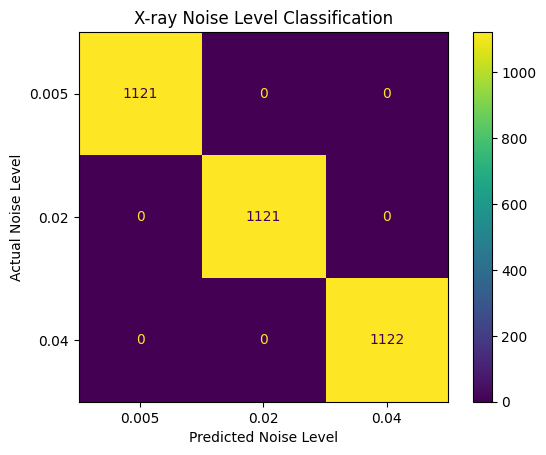


Feature Importance:


,Feature,Importance
1,sharpness,0.474200
0,noise_var,0.388030
3,mean_intensity,0.073871
4,std_intensity,0.048576
2,entropy,0.015323


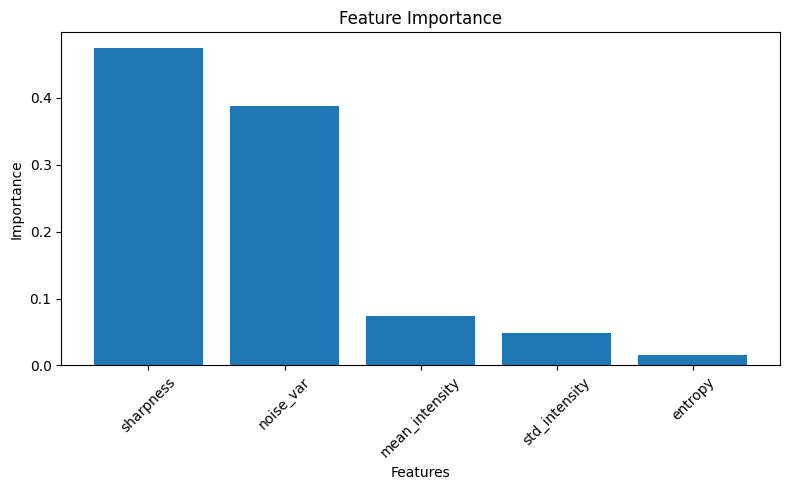

In [ ]:
# ==========================================
# X-RAY NOISE LEVEL CLASSIFICATION PROJECT
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# Step 1: Load Dataset

df = pd.read_csv("/content/x-raydose.csv")

print("Dataset Shape:", df.shape)


# Step 2: Select Input Features (X)

X = df[
    [
        "noise_var",
        "sharpness",
        "entropy",
        "mean_intensity",
        "std_intensity"
    ]
]


# Step 3: Select Target (y)
# Convert noise levels into categorical labels

y = df["noise_std"].astype(str)

print("\nTarget Classes:")
print(y.unique())


# Step 4: Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# Step 5: Create Model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# Step 6: Train Model

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# Step 7: Make Predictions

y_pred = model.predict(X_test)


# Step 8: Model Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")


# Step 9: Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Step 10: Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

print("\nConfusion Matrix:")
print(cm)


# Step 11: Display Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("X-ray Noise Level Classification")
plt.xlabel("Predicted Noise Level")
plt.ylabel("Actual Noise Level")
plt.show()


# Step 12: Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
display(feature_importance)


# Step 13: Feature Importance Graph

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()